# Notebook 12b - Quantum Oracles, Algorithm Primitives, and Deutsch–Jozsa (with **Qiskit**)

**on Quantum Computing · Trinexis**

---

**The unifying thesis:**

> Indistinguishable alternatives interfere; probabilities are squared magnitudes of amplitudes.

**Tools:** `qiskit` (2.x) + `qiskit-aer` + NumPy + Matplotlib. Runs cleanly on
Google Colab.

### What is new versus Notebook 12

| Notebook 12 (NumPy) | Notebook 12b (Qiskit) |
|---|---|
| Explicit statevectors as NumPy arrays | `Statevector` and `Operator` objects |
| Oracles built as permutation / diagonal matrices | Oracles built as *circuits* using `mcx`, `mcp`, `x` |
| "Measurement" = compute `|amp|²` | Real shot-based sampling via `AerSimulator` |
| No circuit diagrams | Every algorithm has a rendered circuit diagram |
| - | Introduces Qiskit's little-endian bit-ordering convention explicitly |

### What is unchanged

- The physical anchors (SG cascade, double-slit)
- The four-part algorithm template (state prep → oracle → interference → readout)
- The pedagogical order (uniform superposition → interference → oracles → phase kickback → Deutsch → Deutsch–Jozsa)
- Exercises (three tiers, ★ ★★ ★★★)


## 0 · Setup

In [1]:
# On Colab, uncomment the next line the first time you run the notebook.
%pip install --quiet qiskit qiskit-aer pylatexenc

import numpy as np
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram
import qiskit_aer
from qiskit_aer import AerSimulator

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 100
np.set_printoptions(precision=4, suppress=True)

# A shared simulator for the whole notebook
SIM = AerSimulator()

print("Qiskit    :", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("NumPy     :", np.__version__)
print("Ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
Qiskit    : 2.5.0
Qiskit Aer: 0.17.2
NumPy     : 2.0.2
Ready.


### 0.1 Qiskit conventions we will lean on

**Little-endian labelling.** In Qiskit, qubit index 0 is the least-significant
bit of the statevector index. If we have qubits $q_0, q_1, q_2$, then the state
where $q_0 = 1, q_1 = 0, q_2 = 1$ is written $|q_2 q_1 q_0\rangle = |101\rangle$
and its statevector index is $\mathtt{0b101} = 5$.

This differs from the "MSB first" convention we used in the NumPy notebook -
don't get thrown off when bitstrings look flipped.

**Simulators used here.**

- `Statevector(qc)` - exact statevector after `qc` acts on $|0\ldots 0\rangle$. Great for teaching amplitudes.
- `Operator(qc)` - exact $2^n \times 2^n$ unitary the circuit implements. It is Great for visualizing "what matrix is this?".
- `AerSimulator()` - shot-based sampling. Great for the "measurement gives counts" mental model.

**Register layout (used consistently below).**

For any $n$-input Boolean function $f$, we build oracles with $n+1$ qubits:

- `q[0], q[1], ..., q[n-1]` - the data register (bit $i$ of $x$ lives on `q[i]`).
- `q[n]` - the ancilla.

### 0.2 Shared toolkit

In [2]:
def int_to_bits_lsb(x, n):
    '''Integer x -> list of n bits with LSB first (Qiskit ordering).'''
    return [(x >> i) & 1 for i in range(n)]

def bits_lsb_to_int(bits):
    '''Inverse of int_to_bits_lsb.'''
    return sum(b << i for i, b in enumerate(bits))

def prepare_basis_state(qc, x, n_data):
    '''Flip the data qubits so that the register holds |x>.  Modifies qc in place.'''
    for i in range(n_data):
        if (x >> i) & 1:
            qc.x(i)

def statevector_of(qc):
    '''Return the statevector produced by qc acting on |0..0>.'''
    return Statevector(qc).data

def is_unitary(mat, tol=1e-9):
    n = mat.shape[0]
    return np.allclose(mat @ mat.conj().T, np.eye(n), atol=tol)

def run_counts(qc, shots=2048):
    '''Transpile and run on AerSimulator; return counts dict.'''
    tqc = transpile(qc, SIM)
    result = SIM.run(tqc, shots=shots).result()
    return result.get_counts()

def marginal_probs(counts, n):
    '''Given counts dict with n-bit string keys, return a length-2^n prob vector.'''
    total = sum(counts.values())
    probs = np.zeros(2**n)
    for bitstring, c in counts.items():
        # keys are little-endian strings: leftmost char = highest qubit
        # convert to int
        idx = int(bitstring, 2)
        probs[idx] = c / total
    return probs

print("Toolkit loaded.")

Toolkit loaded.


---

## 1 · What is a *primitive* of a quantum algorithm?

A **quantum algorithm primitive** is a reusable building block. There are four
canonical roles:

| Primitive | Job | Concrete Qiskit gate/pattern |
|---|---|---|
| **State preparation** | Put the register into a known superposition | `qc.h(range(n))` |
| **Oracle query** | Encode $f$ as a unitary | `qc.mcx`, `qc.mcp`, custom subcircuits |
| **Phase manipulation** | Attach controlled phases | phase kickback with an ancilla in $\lvert -\rangle$ |
| **Interference & readout** | Cash the phases in for probabilities | `qc.h(range(n))` again + `qc.measure(...)` |

Almost every algorithm you meet - Deutsch–Jozsa, Bernstein–Vazirani, Simon,
Grover, QPE, Shor - is a **sandwich** of these primitives around one or more
oracle queries.

### 1.1 Uniform superposition - the workhorse of multiple algorithms

$$
H^{\otimes n}\,\lvert 0\rangle^{\otimes n} \;=\; \frac{1}{\sqrt{2^{n}}}\sum_{x=0}^{2^{n}-1}\lvert x\rangle.
$$

Let us build it as a Qiskit circuit and check.

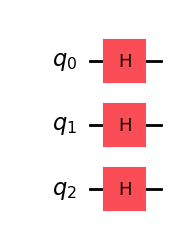

n = 1: each amplitude = 0.7071   (expected 1/sqrt(2) = 0.7071)   total prob = 1.0000
n = 2: each amplitude = 0.5000   (expected 1/sqrt(4) = 0.5000)   total prob = 1.0000
n = 3: each amplitude = 0.3536   (expected 1/sqrt(8) = 0.3536)   total prob = 1.0000


In [3]:
def uniform_superposition_circuit(n):
    qc = QuantumCircuit(n, name=f"H^{n}|0..0>")
    qc.h(range(n))
    return qc

# Draw and check for n=3
qc3 = uniform_superposition_circuit(3)
display(qc3.draw('mpl'))

for n in [1, 2, 3]:
    sv = statevector_of(uniform_superposition_circuit(n))
    print(f"n = {n}: each amplitude = {sv[0].real:.4f}   "
          f"(expected 1/sqrt({2**n}) = {1/np.sqrt(2**n):.4f})   "
          f"total prob = {(np.abs(sv)**2).sum():.4f}")

**Misconception to preempt.** Measuring $H^{\otimes n}\lvert 0\rangle^{\otimes n}$
now gives a uniformly random $x$ - a classical fair coin. The uniform
superposition is a *starting line*, not the speedup. The speedup comes when
we then attach non-trivial phases (oracle) and interfere (final Hadamards).

### 1.2 Interference - a two-Hadamard demonstration

$H\cdot H = I$: the simplest possible interference experiment. Insert a phase
in the middle ($Z$) and it flips to $X$. Insert a bit-flip ($X$) and it flips
to $Z$. Same superposition, different phases, different outcome.

**Physical picture:** this is the Mach–Zehnder / double-slit equivalent. The first
$H$ opens two paths; the second $H$ closes them. Constructive interference
along one output, destructive along the other.

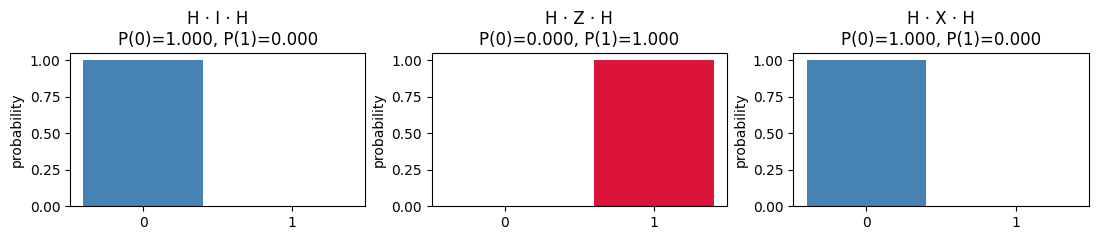

H·I·H = I : constructive interference into |0>
H·Z·H = X : Z flips the phase of one path -> constructive into |1>
H·X·H = Z : X swaps the paths -> visible only in a |+/-> measurement (here we still measure in Z and see |0>)


In [4]:
def sandwich_circuit(middle_op_name):
    '''H then <middle> then H on a single qubit, with measurement.'''
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    if middle_op_name == "I":
        pass
    elif middle_op_name == "Z":
        qc.z(0)
    elif middle_op_name == "X":
        qc.x(0)
    else:
        raise ValueError(middle_op_name)
    qc.h(0)
    qc.measure(0, 0)
    return qc

fig, axes = plt.subplots(1, 3, figsize=(11, 2.5))
for ax, op in zip(axes, ["I", "Z", "X"]):
    qc = sandwich_circuit(op)
    counts = run_counts(qc, shots=4096)
    p0 = counts.get('0', 0) / 4096
    p1 = counts.get('1', 0) / 4096
    ax.bar(['0', '1'], [p0, p1], color=['steelblue', 'crimson'])
    ax.set_title(f"H · {op} · H\nP(0)={p0:.3f}, P(1)={p1:.3f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("probability")

plt.tight_layout(); plt.show()

print("H·I·H = I : constructive interference into |0>")
print("H·Z·H = X : Z flips the phase of one path -> constructive into |1>")
print("H·X·H = Z : X swaps the paths -> visible only in a |+/-> measurement (here we still measure in Z and see |0>)")

---

## 2 · Quantum Oracles

An **oracle** is a black-box unitary encoding a classical function
$f:\{0,1\}^n\!\to\!\{0,1\}$. Two constraints:

1. **Unitary** - every quantum op is unitary, so the oracle must be too.
2. **Reversible** - but a general classical $f$ is not invertible. So we cannot
   just build $\lvert x\rangle \mapsto \lvert f(x)\rangle$.

Two standard workarounds:

- **Bit-flip (XOR) oracle** $U_f\lvert x\rangle\lvert y\rangle = \lvert x\rangle\lvert y \oplus f(x)\rangle$.
- **Phase oracle** $O_f\lvert x\rangle = (-1)^{f(x)}\lvert x\rangle$.

We will see that with the ancilla in $\lvert -\rangle$ these two are the same
operation - **phase kickback**.

### 2.1 Building the bit-flip oracle as a Qiskit circuit

For each $x$ with $f(x)=1$: sandwich `x` gates on the data qubits where $x$
has a `0` bit, then apply `mcx` from all data qubits into the ancilla.
The sandwich uncomputes to restore the input register.

Bit-flip oracle for f = parity on 2 bits:


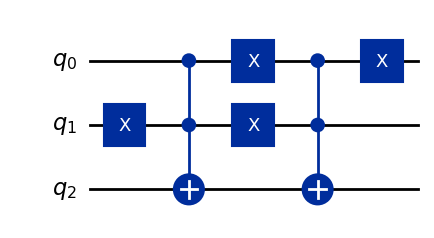

Matrix shape: (8, 8)
Unitary?      True


In [5]:
def bitflip_oracle_circuit(f, n):
    '''
    (n+1)-qubit circuit implementing U_f|x>|y> = |x>|y XOR f(x)>.
    Qubits 0..n-1 are data (bit i on qubit i, LSB first).
    Qubit n is the ancilla.
    '''
    qc = QuantumCircuit(n + 1, name="U_f")
    for x in range(2**n):
        if f(x) & 1 == 0:
            continue
        # 'select' the pattern x by X-sandwiching the 0-bits
        for i in range(n):
            if ((x >> i) & 1) == 0:
                qc.x(i)
        # multi-controlled X into the ancilla
        if n == 1:
            qc.cx(0, 1)
        else:
            qc.mcx(list(range(n)), n)
        # uncompute the selection X's
        for i in range(n):
            if ((x >> i) & 1) == 0:
                qc.x(i)
    return qc

# --- demo: parity on 2 bits, f(x0, x1) = x0 XOR x1 ---
def f_parity(x):
    return ((x >> 0) ^ (x >> 1)) & 1

qc_Uf = bitflip_oracle_circuit(f_parity, n=2)
print("Bit-flip oracle for f = parity on 2 bits:")
display(qc_Uf.draw('mpl'))

# --- verify unitary ---
U = Operator(qc_Uf).data
print(f"Matrix shape: {U.shape}")
print(f"Unitary?      {is_unitary(U)}")

### Verify the action of $U_f$ on all computational basis states

We prepare each $\lvert x\rangle\lvert y\rangle$, apply $U_f$, and read off the
resulting basis state.

In [6]:
def _basis_label(idx, n_data, n_anc=1):
    # returns "y ; x_{n-1} ... x_0" style label
    y_bits = (idx >> n_data) & ((1 << n_anc) - 1)
    x_bits = idx & ((1 << n_data) - 1)
    return f"|x={x_bits:0{n_data}b}⟩|y={y_bits}⟩"

for x in range(4):
    for y in range(2):
        qc = QuantumCircuit(3)
        prepare_basis_state(qc, x, 2)
        if y: qc.x(2)
        qc.compose(qc_Uf, inplace=True)
        sv = statevector_of(qc)
        out_idx = int(np.argmax(np.abs(sv)))
        fx = f_parity(x)
        print(f"{_basis_label((y<<2)|x, 2):24s} ->  {_basis_label(out_idx, 2):24s}  "
              f"(f(x)={fx},  y XOR f(x)={y^fx})")

|x=00⟩|y=0⟩              ->  |x=00⟩|y=0⟩               (f(x)=0,  y XOR f(x)=0)
|x=00⟩|y=1⟩              ->  |x=00⟩|y=1⟩               (f(x)=0,  y XOR f(x)=1)
|x=01⟩|y=0⟩              ->  |x=01⟩|y=1⟩               (f(x)=1,  y XOR f(x)=1)
|x=01⟩|y=1⟩              ->  |x=01⟩|y=0⟩               (f(x)=1,  y XOR f(x)=0)
|x=10⟩|y=0⟩              ->  |x=10⟩|y=1⟩               (f(x)=1,  y XOR f(x)=1)
|x=10⟩|y=1⟩              ->  |x=10⟩|y=0⟩               (f(x)=1,  y XOR f(x)=0)
|x=11⟩|y=0⟩              ->  |x=11⟩|y=0⟩               (f(x)=0,  y XOR f(x)=0)
|x=11⟩|y=1⟩              ->  |x=11⟩|y=1⟩               (f(x)=0,  y XOR f(x)=1)


### 2.2 Building the phase oracle as a Qiskit circuit

The phase oracle marks state $\lvert x\rangle$ with a $-1$ whenever $f(x)=1$.
Same X-sandwich trick, but the multi-controlled operation is $Z$ instead of $X$.

- For $n=1$: `qc.z(0)`.
- For $n\ge 2$: `qc.mcp(π, controls, target)` - a multi-controlled phase gate
  with angle $\pi$ is exactly a multi-controlled $Z$.

Phase oracle for f = parity on 2 bits:


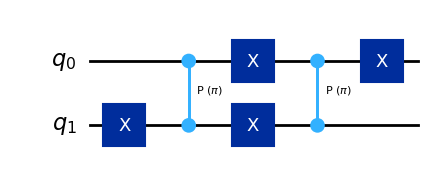

Operator matrix O_f (real part):
[[ 1.  0.  0.  0.]
 [ 0. -1.  0.  0.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0.  1.]]

Diagonal: [ 1. -1. -1.  1.]   (should be (-1)^f(x) for x = 0,1,2,3)
Unitary? True


In [7]:
def phase_oracle_circuit(f, n):
    '''n-qubit circuit implementing O_f|x> = (-1)^f(x) |x>.'''
    qc = QuantumCircuit(n, name="O_f")
    for x in range(2**n):
        if f(x) & 1 == 0:
            continue
        for i in range(n):
            if ((x >> i) & 1) == 0:
                qc.x(i)
        if n == 1:
            qc.z(0)
        else:
            qc.mcp(np.pi, list(range(n - 1)), n - 1)
        for i in range(n):
            if ((x >> i) & 1) == 0:
                qc.x(i)
    return qc

qc_Of = phase_oracle_circuit(f_parity, n=2)
print("Phase oracle for f = parity on 2 bits:")
display(qc_Of.draw('mpl'))

# Show the resulting matrix
O = Operator(qc_Of).data
print("Operator matrix O_f (real part):")
print(O.real)
print(f"\nDiagonal: {O.diagonal().real}   (should be (-1)^f(x) for x = 0,1,2,3)")
print("Unitary?", is_unitary(O))

### 2.3 Phase kickback - the identity that ties them together

Prepare the ancilla in $\lvert -\rangle = \tfrac{1}{\sqrt{2}}(\lvert 0\rangle - \lvert 1\rangle)$.
Then

$$
U_f\,\lvert x\rangle\!\lvert -\rangle
\;=\; (-1)^{f(x)}\,\lvert x\rangle\!\lvert -\rangle.
$$

The $\pm 1$ that *should* have been written into the ancilla has **kicked
back** into the phase of the data register. The ancilla is unchanged.

> With the ancilla in $\lvert -\rangle$, running $U_f$ is *identical* to
> running $O_f$ on the data register.

Every algorithm on the primitives board - Deutsch, DJ, BV, Grover - starts
by preparing the ancilla in $\lvert -\rangle$ precisely so the bit-flip oracle
we're given acts as the phase oracle we want.

### Numerical verification with Qiskit

Prepare $\lvert x\rangle\lvert -\rangle$, run $U_f$, and compare the resulting
statevector with $O_f\lvert x\rangle$ tensored with $\lvert -\rangle$.

In [8]:
max_err = 0.0
print("For each basis state |x> of the 2-qubit data register:\n")
for x in range(4):
    # LHS: |x>|-> then U_f
    lhs = QuantumCircuit(3)
    prepare_basis_state(lhs, x, 2)
    lhs.x(2); lhs.h(2)                          # ancilla -> |->
    lhs.compose(bitflip_oracle_circuit(f_parity, 2), inplace=True)
    sv_lhs = statevector_of(lhs)

    # RHS: O_f|x> tensored with |->
    rhs = QuantumCircuit(3)
    prepare_basis_state(rhs, x, 2)
    rhs.compose(phase_oracle_circuit(f_parity, 2), qubits=[0, 1], inplace=True)
    rhs.x(2); rhs.h(2)
    sv_rhs = statevector_of(rhs)

    err = np.linalg.norm(sv_lhs - sv_rhs)
    max_err = max(max_err, err)
    sign = -1 if f_parity(x) else +1
    print(f"  x = {x:02b}   f(x) = {f_parity(x)}   phase = {sign:+d}   |LHS - RHS| = {err:.2e}")

print(f"\nMax discrepancy over all x: {max_err:.2e}   [OK]")

For each basis state |x> of the 2-qubit data register:

  x = 00   f(x) = 0   phase = +1   |LHS - RHS| = 0.00e+00
  x = 01   f(x) = 1   phase = -1   |LHS - RHS| = 1.22e-16
  x = 10   f(x) = 1   phase = -1   |LHS - RHS| = 1.22e-16
  x = 11   f(x) = 0   phase = +1   |LHS - RHS| = 0.00e+00

Max discrepancy over all x: 1.22e-16   [OK]


### 2.4 Visualising the phase pattern

$O_f$ turns the uniform superposition into a signed superposition. Plotting
the amplitudes as $\pm 1/\sqrt{2^n}$ makes the pattern obvious.

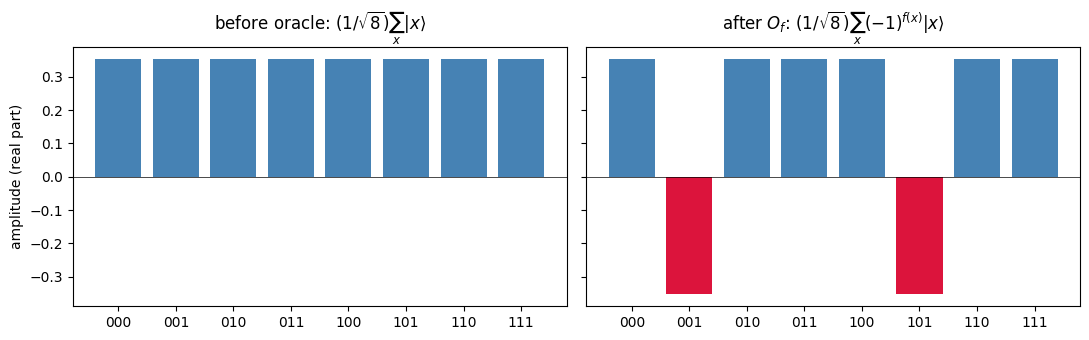

Truth table used (x written as b2 b1 b0):
  f(000) = 0
  f(001) = 1
  f(010) = 0
  f(011) = 0
  f(100) = 0
  f(101) = 1
  f(110) = 0
  f(111) = 0
Red bars are the x's that O_f marked with -1.


In [9]:
def f_demo(x):
    b0 = x & 1
    b1 = (x >> 1) & 1
    return int(b0 == 1 and b1 == 0)   # marks x's with (b0=1, b1=0)

n = 3
qc_before = uniform_superposition_circuit(n)
qc_after  = qc_before.compose(phase_oracle_circuit(f_demo, n))

sv_before = statevector_of(qc_before)
sv_after  = statevector_of(qc_after)

# Qiskit's little-endian labels: bit i of x on qubit i
labels = [format(x, f'0{n}b') for x in range(2**n)]
xpos   = np.arange(2**n)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
axes[0].bar(xpos, sv_before.real, color='steelblue')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title(r"before oracle: $(1/\sqrt{8})\sum_x |x\rangle$")
axes[0].set_xticks(xpos); axes[0].set_xticklabels(labels)
axes[0].set_ylabel("amplitude (real part)")
axes[1].bar(xpos, sv_after.real,
            color=['crimson' if a < 0 else 'steelblue' for a in sv_after.real])
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title(r"after $O_f$: $(1/\sqrt{8})\sum_x (-1)^{f(x)}|x\rangle$")
axes[1].set_xticks(xpos); axes[1].set_xticklabels(labels)
plt.tight_layout(); plt.show()

print("Truth table used (x written as b2 b1 b0):")
for x in range(2**n):
    print(f"  f({format(x, f'0{n}b')}) = {f_demo(x)}")
print("Red bars are the x's that O_f marked with -1.")

---

## 3 · Deutsch's Algorithm - the quantum speedup

**Setup.** Given $f: \{0,1\} \to \{0,1\}$ (one of four possible functions),
decide whether $f$ is *constant* or *balanced*.

| Name | $f(0)$ | $f(1)$ | Type |
|---|---|---|---|
| constant-0 | 0 | 0 | constant |
| constant-1 | 1 | 1 | constant |
| identity   | 0 | 1 | balanced |
| NOT        | 1 | 0 | balanced |

Classical query complexity: **2**. Quantum: **1**.

### 3.1 Circuit

Prepare $\lvert 0\rangle\lvert 1\rangle$, apply $H\otimes H$, then $U_f$, then
$H$ on the data qubit, then measure the data qubit.

### 3.2 Amplitude walk (short form)

$$
\begin{aligned}
\lvert \psi_0\rangle &= \lvert 0\rangle\lvert 1\rangle \\
\xrightarrow{H\otimes H} \lvert \psi_1\rangle &= \lvert +\rangle\lvert -\rangle \\
\xrightarrow{U_f} \lvert \psi_2\rangle &= \tfrac{1}{\sqrt 2}\bigl((-1)^{f(0)}\lvert 0\rangle + (-1)^{f(1)}\lvert 1\rangle\bigr)\lvert -\rangle \\
&\propto \tfrac{1}{\sqrt 2}\bigl(\lvert 0\rangle + (-1)^{s}\lvert 1\rangle\bigr)\lvert -\rangle,\quad s = f(0)\oplus f(1) \\
\xrightarrow{H\otimes I} \lvert \psi_3\rangle &= \lvert s\rangle\lvert -\rangle
\end{aligned}
$$

Measure the data qubit: **`0` ⇒ constant, `1` ⇒ balanced.** Deterministic.

Deutsch circuit on f(x) = x  (balanced):


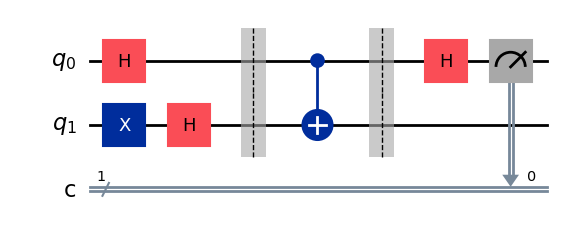

In [10]:
def deutsch_circuit(f, draw=False):
    qc = QuantumCircuit(2, 1)
    # initial state |0>|1>
    qc.x(1)
    # H x H
    qc.h(0); qc.h(1)
    qc.barrier()
    # oracle
    qc.compose(bitflip_oracle_circuit(f, 1), inplace=True)
    qc.barrier()
    # H on data
    qc.h(0)
    qc.measure(0, 0)
    if draw:
        display(qc.draw('mpl'))
    return qc

# Draw an example (identity)
print("Deutsch circuit on f(x) = x  (balanced):")
_ = deutsch_circuit(lambda x: x, draw=True)

### 3.3 Test on all four one-bit functions

In [11]:
funcs = {
    "constant-0 (f=0)":  (lambda x: 0, "constant"),
    "constant-1 (f=1)":  (lambda x: 1, "constant"),
    "identity  (f=x)":   (lambda x: x, "balanced"),
    "NOT       (f=1-x)": (lambda x: 1 - x, "balanced"),
}

shots = 2048
print(f"{'function':22s}  {'counts':>16s}   verdict   expected")
print("-" * 72)
for name, (f, expected) in funcs.items():
    counts = run_counts(deutsch_circuit(f), shots=shots)
    top = max(counts, key=counts.get)
    verdict = "constant" if top == '0' else "balanced"
    status  = "OK" if verdict == expected else "MISMATCH"
    print(f"{name:22s}  {str(counts):>16s}   {verdict:8s}  {expected:8s}  [{status}]")

function                          counts   verdict   expected
------------------------------------------------------------------------
constant-0 (f=0)             {'0': 2048}   constant  constant  [OK]
constant-1 (f=1)             {'0': 2048}   constant  constant  [OK]
identity  (f=x)              {'1': 2048}   balanced  balanced  [OK]
NOT       (f=1-x)            {'1': 2048}   balanced  balanced  [OK]


And a histogram for the two visually distinct cases:

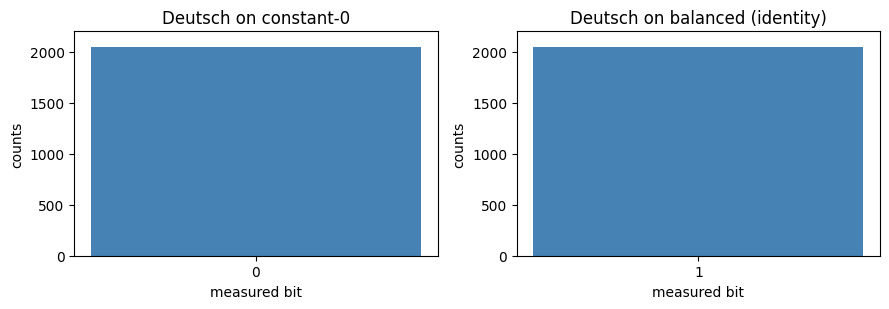

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, (name, (f, _)) in zip(axes, [('constant-0', funcs["constant-0 (f=0)"]),
                                      ('balanced (identity)', funcs["identity  (f=x)"])]):
    counts = run_counts(deutsch_circuit(f), shots=2048)
    ax.bar(counts.keys(), counts.values(), color='steelblue')
    ax.set_title(f"Deutsch on {name}")
    ax.set_xlabel("measured bit")
    ax.set_ylabel("counts")
    ax.set_ylim(0, 2200)
plt.tight_layout(); plt.show()

---

## 4 · Deutsch–Jozsa Algorithm - generalising to $n$ bits

**Promise.** $f: \{0,1\}^n \to \{0,1\}$ is either
- **constant** (returns the same bit for every input), or
- **balanced** (returns 0 for exactly half the inputs, 1 for the other half).

Decide which.

**Classical (deterministic) query complexity:** worst case $2^{n-1}+1$.
**Quantum:** **1**.

### 4.1 The circuit

Data register: $n$ qubits, initial state $\lvert 0\rangle^{\otimes n}$.
Ancilla: 1 qubit, initial state $\lvert 1\rangle$.

$$
\text{data: } \lvert 0\rangle^{\otimes n} - H^{\otimes n} - \boxed{U_f} - H^{\otimes n} - \text{measure}
$$
$$
\text{anc:  } \lvert 1\rangle - H - \boxed{U_f} - -
$$

### 4.2 Amplitude walk

Setting $\lvert -\rangle$ on the ancilla and using $H^{\otimes n}\lvert x\rangle = \tfrac{1}{\sqrt{2^n}}\sum_z (-1)^{x\cdot z}\lvert z\rangle$:

$$
\alpha_z \;=\; \frac{1}{2^n}\sum_x (-1)^{f(x)+x\cdot z}.
$$

For $z = 0^n$:
$\alpha_0 = \tfrac{1}{2^n}\sum_x (-1)^{f(x)}$ which is $\pm 1$ if $f$ is
constant and $0$ if $f$ is balanced.

**Read-out.** Measure the data register. All zeros $\Rightarrow$ constant;
anything else $\Rightarrow$ balanced.

### 4.3 Implementation

Deutsch-Jozsa circuit for n = 3, f(x) = LSB(x) (balanced):


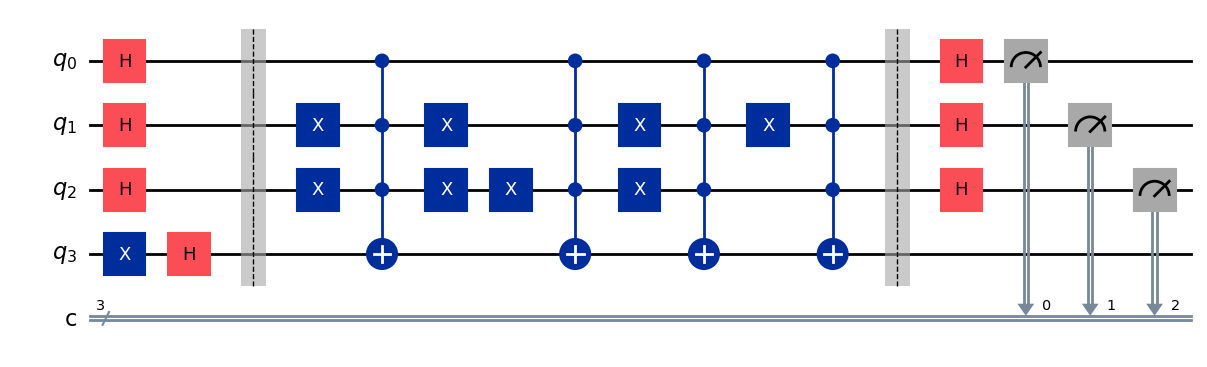

In [26]:
def deutsch_jozsa_circuit(f, n, draw=False):
    qc = QuantumCircuit(n + 1, n)
    # initial state |0..0>|1>
    qc.x(n)
    # H on all n+1 qubits
    for q in range(n + 1):
        qc.h(q)
    qc.barrier()
    # oracle
    qc.compose(bitflip_oracle_circuit(f, n), inplace=True)
    qc.barrier()
    # H on the data register only
    for q in range(n):
        qc.h(q)
    # measure the data register
    qc.measure(range(n), range(n))
    if draw:
        display(qc.draw('mpl'))
    return qc

# Draw a DJ circuit on n = 3 with a specific balanced function
def f_balanced_demo(x):
    # returns bit 0 of x (balanced: half 0s, half 1s)
    return x & 1

print("Deutsch-Jozsa circuit for n = 3, f(x) = LSB(x) (balanced):")
_ = deutsch_jozsa_circuit(f_balanced_demo, 3, draw=True)

### 4.4 Case A - constant functions

$P(\text{all-zeros}) = 1$ exactly.

In [27]:
n = 3
shots = 2048
print(f"n = {n}, shots = {shots}\n")

for label, f in [("constant-0", lambda x: 0), ("constant-1", lambda x: 1)]:
    counts = run_counts(deutsch_jozsa_circuit(f, n), shots=shots)
    all_zeros = '0' * n
    p0 = counts.get(all_zeros, 0) / shots
    verdict = "constant" if p0 > 0.99 else "balanced"
    print(f"  {label:12s}: counts = {counts}, P('{all_zeros}') = {p0:.4f}, verdict = {verdict}")

n = 3, shots = 2048

  constant-0  : counts = {'000': 2048}, P('000') = 1.0000, verdict = constant
  constant-1  : counts = {'000': 2048}, P('000') = 1.0000, verdict = constant


### 4.5 Case B - balanced functions

$P(\text{all-zeros}) = 0$ exactly.

In [28]:
def make_balanced_from_tt(tt):
    '''tt: length-2^n array of bits, must have exactly 2^(n-1) ones.'''
    return lambda x, tt=tt: int(tt[x])

def random_balanced_tt(n, rng):
    tt = np.array([1] * (2**(n-1)) + [0] * (2**(n-1)))
    rng.shuffle(tt)
    return tt

rng = np.random.default_rng(42)
n = 3

# a fixed illustrative balanced function
tt_fixed = np.array([0, 1, 0, 1, 1, 0, 1, 0])
f = make_balanced_from_tt(tt_fixed)
counts = run_counts(deutsch_jozsa_circuit(f, n), shots=shots)
p0 = counts.get('000', 0) / shots
print(f"balanced tt = {tt_fixed.tolist()}: counts = {counts}")
print(f"  P('000') = {p0:.4f}, verdict = {'balanced' if p0 < 1e-6 else 'constant'}\n")

# three random balanced instances
for trial in range(3):
    tt = random_balanced_tt(n, rng)
    f = make_balanced_from_tt(tt)
    counts = run_counts(deutsch_jozsa_circuit(f, n), shots=shots)
    p0 = counts.get('000', 0) / shots
    print(f"random balanced tt = {tt.tolist()}: '000' in counts? {('000' in counts)}, P('000') = {p0:.4f}")

balanced tt = [0, 1, 0, 1, 1, 0, 1, 0]: counts = {'101': 2048}
  P('000') = 0.0000, verdict = balanced

random balanced tt = [1, 0, 1, 0, 0, 1, 0, 1]: '000' in counts? False, P('000') = 0.0000
random balanced tt = [1, 1, 0, 1, 0, 0, 1, 0]: '000' in counts? False, P('000') = 0.0000
random balanced tt = [0, 0, 1, 0, 1, 0, 1, 1]: '000' in counts? False, P('000') = 0.0000


### 4.6 Side-by-side histogram - constant vs balanced

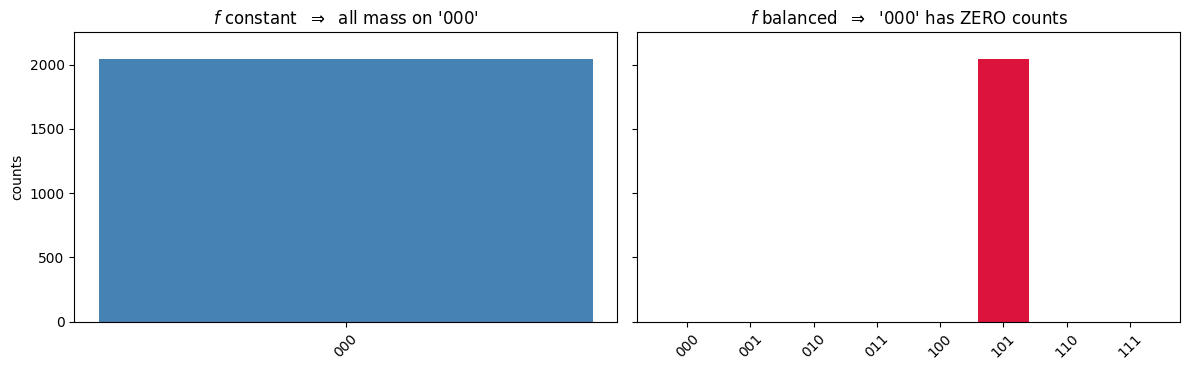

P('000') constant = 1.0000   [expect 1.0000]
P('000') balanced = 0.0000   [expect 0.0000]


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)

f_c = lambda x: 0
counts_c = run_counts(deutsch_jozsa_circuit(f_c, n), shots=shots)
axes[0].bar(counts_c.keys(), counts_c.values(), color='steelblue')
axes[0].set_title(r"$f$ constant  $\Rightarrow$  all mass on '000'")
axes[0].set_ylabel("counts")
axes[0].set_ylim(0, shots * 1.1)

f_b = make_balanced_from_tt(tt_fixed)
counts_b = run_counts(deutsch_jozsa_circuit(f_b, n), shots=shots)
# order the keys as full 3-bit strings for consistent x-axis
all_keys = [format(z, f'0{n}b') for z in range(2**n)]
values_b = [counts_b.get(k, 0) for k in all_keys]
axes[1].bar(all_keys, values_b, color='crimson')
axes[1].set_title(r"$f$ balanced  $\Rightarrow$  '000' has ZERO counts")
axes[1].set_ylim(0, shots * 1.1)
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print(f"P('000') constant = {counts_c.get('000', 0)/shots:.4f}   [expect 1.0000]")
print(f"P('000') balanced = {counts_b.get('000', 0)/shots:.4f}   [expect 0.0000]")

### 4.7 Exact analysis via `Statevector`

Shots give sample estimates; let us also confirm the *exact* probabilities
using `Statevector` (no measurement, no sampling noise).

In [17]:
def dj_exact_probs(f, n):
    '''Return the length-2^n exact probability distribution for the data register.'''
    qc = QuantumCircuit(n + 1)  # no classical bits
    qc.x(n)
    for q in range(n + 1):
        qc.h(q)
    qc.compose(bitflip_oracle_circuit(f, n), inplace=True)
    for q in range(n):
        qc.h(q)
    sv = Statevector(qc).data
    probs_data = np.zeros(2**n)
    for idx, amp in enumerate(sv):
        # data bits are the low n bits of idx (Qiskit little-endian)
        x = idx & ((1 << n) - 1)
        probs_data[x] += abs(amp)**2
    return probs_data

for label, f in [("constant-0", lambda x: 0),
                 ("balanced (tt = " + str(tt_fixed.tolist()) + ")",
                  make_balanced_from_tt(tt_fixed))]:
    p = dj_exact_probs(f, 3)
    print(f"{label}:")
    print(f"  exact P(x) = {p}")
    print(f"  P('000') = {p[0]:.6f}\n")

constant-0:
  exact P(x) = [1. 0. 0. 0. 0. 0. 0. 0.]
  P('000') = 1.000000

balanced (tt = [0, 1, 0, 1, 1, 0, 1, 0]):
  exact P(x) = [0. 0. 0. 0. 0. 1. 0. 0.]
  P('000') = 0.000000



### 4.8 Scaling - does it still work at $n = 4, 5$?

In [30]:
rng = np.random.default_rng(42)

print(f"{'n':>3s}  {'trials':>7s}  {'max P(all-zeros) over balanced trials':>42s}")
print("-" * 60)
for n in range(2, 6):
    max_leak = 0.0
    trials = 30
    for _ in range(trials):
        tt = random_balanced_tt(n, rng)
        f = make_balanced_from_tt(tt)
        p = dj_exact_probs(f, n)
        max_leak = max(max_leak, p[0])
    print(f"{n:>3d}  {trials:>7d}  {max_leak:>42.2e}")

print("\nAll leaks are at machine epsilon. Deutsch-Jozsa reads out the promise")
print("deterministically for every balanced input, using a single oracle query.")

  n   trials       max P(all-zeros) over balanced trials
------------------------------------------------------------
  2       30                                    9.07e-35
  3       30                                    2.96e-32
  4       30                                    2.93e-31
  5       30                                    7.10e-30

All leaks are at machine epsilon. Deutsch-Jozsa reads out the promise
deterministically for every balanced input, using a single oracle query.


### 4.9 Classical vs quantum query counts

In [19]:
print(f"{'n':>3s}  {'inputs 2^n':>12s}  {'classical deterministic':>25s}  {'quantum':>8s}")
print("-" * 60)
for n in [1, 2, 3, 5, 10, 20]:
    print(f"{n:>3d}  {2**n:>12d}  {2**(n-1)+1:>25d}  {1:>8d}")

  n    inputs 2^n    classical deterministic   quantum
------------------------------------------------------------
  1             2                          2         1
  2             4                          3         1
  3             8                          5         1
  5            32                         17         1
 10          1024                        513         1
 20       1048576                     524289         1


### 4.10 Bar-chart with `plot_histogram` - the Qiskit-native way

In [31]:
# plot_histogram works directly with a counts dict; nice for exposition
n = 3; shots = 4096
f_c = lambda x: 0
f_b = make_balanced_from_tt(tt_fixed)
counts_c = run_counts(deutsch_jozsa_circuit(f_c, n), shots=shots)
counts_b = run_counts(deutsch_jozsa_circuit(f_b, n), shots=shots)
fig = plot_histogram([counts_c, counts_b],
                     legend=['constant-0', 'balanced'],
                     title='Deutsch-Jozsa (n = 3)  -  Qiskit plot_histogram')
plt.tight_layout(); plt.show()

<Figure size 700x400 with 0 Axes>

### 4.11 Optional interactive playground

Slider for $n$, dropdown for function type. If `ipywidgets` isn't available
(headless environments), the cell falls back to a static demonstration.

In [21]:
try:
    from ipywidgets import interact, IntSlider, Text, Dropdown
    from IPython.display import display as ip_display

    def dj_widget(n=3, kind='balanced (auto)', custom_tt=''):
        if kind == 'constant-0':
            f = lambda x: 0; tt = [0]*(2**n)
        elif kind == 'constant-1':
            f = lambda x: 1; tt = [1]*(2**n)
        elif kind == 'balanced (auto)':
            tt = [0]*(2**(n-1)) + [1]*(2**(n-1))
            f = lambda x, tt=tt: tt[x]
        else:  # custom
            try:
                tt = [int(b) for b in custom_tt.strip() if b in '01']
                if len(tt) != 2**n:
                    print(f"Truth table needs {2**n} bits, got {len(tt)}."); return
                f = lambda x, tt=tt: tt[x]
            except Exception as e:
                print("Bad custom truth table:", e); return

        p = dj_exact_probs(f, n)
        fig, ax = plt.subplots(figsize=(7, 3.2))
        labels = [format(z, f'0{n}b') for z in range(2**n)]
        colors = ['crimson' if pk > 1e-9 else 'lightgrey' for pk in p]
        ax.bar(labels, p, color=colors)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("P(z)")
        s = sum(tt)
        expected = 'balanced' if s == 2**(n-1) else ('constant' if s in (0, 2**n) else 'NEITHER (breaks promise)')
        verdict = "constant" if p[0] > 1 - 1e-6 else "balanced"
        ax.set_title(f"DJ, n = {n} | tt = {tt} | verdict: {verdict}")
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout(); plt.show()
        print(f"Sum(tt) = {s}   truth-table type: {expected}")

    interact(dj_widget,
             n=IntSlider(min=1, max=4, step=1, value=3),
             kind=Dropdown(options=['constant-0','constant-1','balanced (auto)','custom'],
                           value='balanced (auto)'),
             custom_tt=Text(value='', description='custom TT'))
except Exception as e:
    print("ipywidgets unavailable - running static demo.")
    print(f"({type(e).__name__}: {e})")
    for kind, f in [("constant-0", lambda x: 0),
                    ("balanced ",  lambda x: x & 1)]:
        p = dj_exact_probs(f, 3)
        print(f"  {kind}: P('000') = {p[0]:.4f}")

interactive(children=(IntSlider(value=3, description='n', max=4, min=1), Dropdown(description='kind', index=2,…

---

## 5 · Exercises

Same three tiers as Notebook 12, now posed in Qiskit terms.

- ★ basic warm-up
- ★★ intermediate
- ★★★ open-ended / stretch

Scaffolds return an obviously wrong output. If your implementation is correct
the sanity block prints `[OK]`.

### Exercise 1 (★) - Build a constant-1 oracle by hand

Write `constant_one_oracle(n)` that returns a `QuantumCircuit` on $n+1$ qubits
implementing $U_f$ for $f\equiv 1$ **without** calling `bitflip_oracle_circuit`.
Hint: for $f\equiv 1$, the ancilla flips *regardless of $x$*.

In [22]:
def constant_one_oracle(n):
    '''YOUR CODE HERE. Return a QuantumCircuit on n+1 qubits.'''
    qc = QuantumCircuit(n + 1, name="U_{f=1}")
    # scaffold: does nothing -> obviously wrong (implements f=0, not f=1)
    return qc

# sanity check
n = 2
your_op = Operator(constant_one_oracle(n)).data
ref_op  = Operator(bitflip_oracle_circuit(lambda x: 1, n)).data
if np.allclose(your_op, ref_op) and is_unitary(your_op):
    print("[OK] your circuit matches the reference oracle for f = 1")
else:
    print("[not yet] your oracle doesn't match. Frobenius diff:",
          np.linalg.norm(your_op - ref_op))

# <details><summary>Solution</summary>
# def constant_one_oracle(n):
#     qc = QuantumCircuit(n + 1)
#     qc.x(n)          # flip the ancilla regardless of x
#     return qc
# </details>

[not yet] your oracle doesn't match. Frobenius diff: 4.0


### Exercise 2 (★★) - Deutsch–Jozsa with the phase oracle directly

Rewrite Deutsch–Jozsa using `phase_oracle_circuit` (no ancilla, no phase
kickback) - a **pure $n$-qubit** circuit - and verify it matches the reference
`dj_exact_probs`.

In [23]:
def dj_phase_version_probs(f, n):
    '''YOUR CODE HERE. Use phase_oracle_circuit, no ancilla. Return length-2^n prob vector.'''
    # scaffold: returns uniform (obviously wrong)
    return np.ones(2**n) / (2**n)

rng = np.random.default_rng(0)
ok = True
for trial in range(5):
    n = 3
    tt = rng.integers(0, 2, size=2**n)
    f = lambda x, tt=tt: int(tt[x])
    ref = dj_exact_probs(f, n)
    yours = dj_phase_version_probs(f, n)
    if not np.allclose(yours, ref, atol=1e-9):
        print(f"trial {trial}: mismatch. yours = {yours.round(4)}, ref = {ref.round(4)}")
        ok = False
print("[OK] phase-oracle DJ matches reference on all trials" if ok else "[not yet]")

# <details><summary>Solution sketch</summary>
# def dj_phase_version_probs(f, n):
#     qc = QuantumCircuit(n)
#     qc.h(range(n))
#     qc.compose(phase_oracle_circuit(f, n), inplace=True)
#     qc.h(range(n))
#     return np.abs(Statevector(qc).data)**2
# </details>

trial 0: mismatch. yours = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125], ref = [0.0625 0.0625 0.0625 0.0625 0.5625 0.0625 0.0625 0.0625]
trial 1: mismatch. yours = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125], ref = [0.5625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625]
trial 2: mismatch. yours = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125], ref = [0.25 0.   0.   0.25 0.25 0.   0.   0.25]
trial 3: mismatch. yours = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125], ref = [0.0625 0.0625 0.0625 0.5625 0.0625 0.0625 0.0625 0.0625]
trial 4: mismatch. yours = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125], ref = [0.25 0.25 0.   0.   0.25 0.25 0.   0.  ]
[not yet]


### Exercise 3 (★★) - Classical randomised query complexity

You sample $k$ independent inputs of an $n$-bit $f$; if all $k$ answers agree
you *guess* "constant", otherwise you *know* it's balanced.

- Compute the probability that a **truly balanced** $f$ fools you.
- Plot for $k = 1..10$.
- How many samples for error $< 0.01$?

(Assume $2^n \gg k$ so we can ignore without-replacement effects.)

k   P(fooled)
  k= 1   1.000000
  k= 2   1.000000
  k= 3   1.000000
  k= 4   1.000000
  k= 5   1.000000
  k= 6   1.000000
  k= 7   1.000000
  k= 8   1.000000
  k= 9   1.000000
  k=10   1.000000


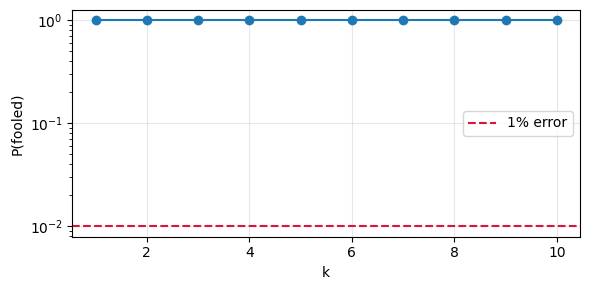

In [24]:
def fool_probability(k):
    '''YOUR CODE HERE. Probability a balanced f gives k identical outputs on k random inputs.'''
    return 1.0  # obviously wrong scaffold

ks = np.arange(1, 11)
probs = np.array([fool_probability(k) for k in ks])
print("k   P(fooled)")
for k, p in zip(ks, probs):
    print(f"  k={k:2d}   {p:.6f}")

plt.figure(figsize=(6, 3))
plt.semilogy(ks, probs, 'o-')
plt.axhline(0.01, color='crimson', ls='--', label='1% error')
plt.xlabel('k'); plt.ylabel('P(fooled)'); plt.grid(True, alpha=0.3)
plt.legend(); plt.tight_layout(); plt.show()

# <details><summary>Solution</summary>
# fool_probability = 2 * (1/2)^k = 2^{-(k-1)}
# k = 8 gives 1/128 < 0.01.
# </details>

### Exercise 4 (★★★) - Beyond the promise

Deutsch–Jozsa assumes the promise. What happens if $f$ has *exactly $k$ ones*
out of $2^n$ inputs?

- Derive $P(\text{all-zeros}) = \left(\dfrac{2^n - 2k}{2^n}\right)^2$.
- Numerically verify by sweeping $k=0,\ldots,2^n$ for $n=4$.
- Interpret: what is the geometric meaning of this formula?

In [25]:
def dj_all_zeros_prob_for_k_ones(n, k):
    '''YOUR CODE HERE. Build any f with exactly k ones, run DJ, return P('0...0').'''
    return -1.0  # scaffold

n = 4
ks = list(range(2**n + 1))
observed  = np.array([dj_all_zeros_prob_for_k_ones(n, k) for k in ks])
predicted = np.array([((2**n - 2*k)/(2**n))**2 for k in ks])

print(f"{'k':>3s}  {'observed':>10s}  {'predicted':>10s}")
for k, o, p in zip(ks, observed, predicted):
    print(f"{k:>3d}  {o:>10.4f}  {p:>10.4f}")

if np.allclose(observed, predicted, atol=1e-9):
    print("\n[OK] Observed matches (1 - 2k/2^n)^2 for all k.")
else:
    print("\n[not yet] some mismatches - check your implementation.")

# <details><summary>Solution outline</summary>
# def dj_all_zeros_prob_for_k_ones(n, k):
#     tt = np.array([1]*k + [0]*(2**n - k))
#     f = lambda x, tt=tt: int(tt[x])
#     p = dj_exact_probs(f, n)
#     return p[0]
#
# The amplitude at |0..0> is (1/2^n) * sum_x (-1)^{f(x)} = (2^n - 2k)/2^n.
# So the probability is its square.
# Geometric meaning: 2k is the Hamming distance between the sign vector and
# the all-plus vector; the probability is the squared cosine of that angle.
# </details>

  k    observed   predicted
  0     -1.0000      1.0000
  1     -1.0000      0.7656
  2     -1.0000      0.5625
  3     -1.0000      0.3906
  4     -1.0000      0.2500
  5     -1.0000      0.1406
  6     -1.0000      0.0625
  7     -1.0000      0.0156
  8     -1.0000      0.0000
  9     -1.0000      0.0156
 10     -1.0000      0.0625
 11     -1.0000      0.1406
 12     -1.0000      0.2500
 13     -1.0000      0.3906
 14     -1.0000      0.5625
 15     -1.0000      0.7656
 16     -1.0000      1.0000

[not yet] some mismatches - check your implementation.


---

## 6 · Summary and forward pointers

### What we built (Qiskit edition)

- **Uniform superposition** with `qc.h(range(n))`.
- **Interference demo** - three tiny circuits (H·I·H, H·Z·H, H·X·H) exercised with `AerSimulator`.
- **Bit-flip oracle** as a Qiskit circuit built from `x`, `cx`, `mcx`.
- **Phase oracle** as a Qiskit circuit built from `x` sandwiches around `z` / `mcp(π, ..., ...)`.
- **Phase kickback** - verified by comparing statevectors of the two constructions on all basis states.
- **Deutsch's algorithm** - implemented as a 2-qubit `QuantumCircuit`; tested on all 4 one-bit functions with real shot-based measurements.
- **Deutsch–Jozsa** - implemented on $n+1$ qubits, tested for constant / balanced, visualised with `plot_histogram`, scaling checked with `Statevector` up to $n = 5$.

### The four-part template - same as before

$$
H^{\otimes n} \;\longrightarrow\; \text{oracle (phase pattern)} \;\longrightarrow\; H^{\otimes n} \;\longrightarrow\; \text{measure}.
$$

Deutsch–Jozsa is the smallest non-trivial instance where this template
appears in its purest form. Bernstein–Vazirani, Simon, Grover, QFT/QPE, Shor
are all reweighted phase patterns or twisted final basis changes on the same
skeleton.

### Common misconceptions revisited

1. *Uniform superposition ≠ speedup.* Measuring $H^{\otimes n}\lvert 0\rangle^{\otimes n}$ gives a uniformly random $x$ - classical coin.
2. *The oracle doesn't "evaluate $f$ on all inputs simultaneously".* It entangles the register with a phase; the *interference* at the end reads out a global property.
3. *The classical baseline is deterministic $2^{n-1}+1$ queries*, not "you can't do it classically". Randomised classical algorithms need $O(1)$ queries for constant error. State this honestly - the deterministic separation is the historical result.

### Suggested homework

- Exercises 1–4 above.
- Try adding depolarising noise via `AerSimulator(noise_model=…)` - a natural
  bridge to Notebook 6's Kraus formalism - and study how the DJ verdict
  degrades with noise strength.
